# inspect the data

In [11]:
# imports

import pandas as pd
import matplotlib.pyplot as plt

(2485, 4)
        Country        Date  \
0        Guinea  2014-08-29   
1       Nigeria  2014-08-29   
2  Sierra Leone  2014-08-29   
3       Liberia  2014-08-29   
4  Sierra Leone  2014-09-05   

   Cumulative no. of confirmed, probable and suspected cases  \
0                                              648.0           
1                                               19.0           
2                                             1026.0           
3                                             1378.0           
4                                             1261.0           

   Cumulative no. of confirmed, probable and suspected deaths  
0                                              430.0           
1                                                7.0           
2                                              422.0           
3                                              694.0           
4                                              491.0           
(365, 4)
    Country        Date  

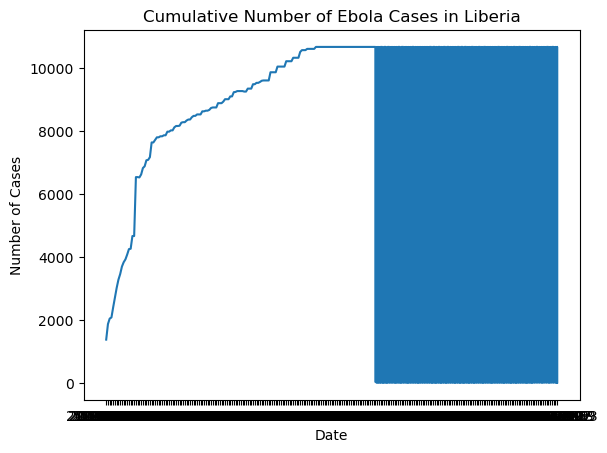

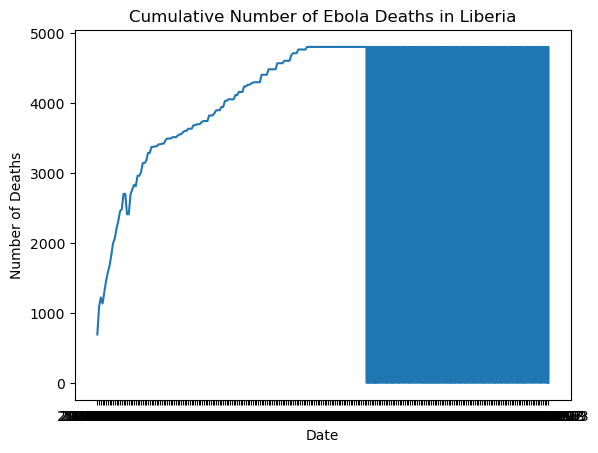

Earliest date: 2014-08-29
Latest date: 2016-03-23


C:\Users\Brooke Brocker\AppData\Local\Temp\ipykernel_11184\842524474.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_liberia["Date"] = pd.to_datetime(df_liberia["Date"])


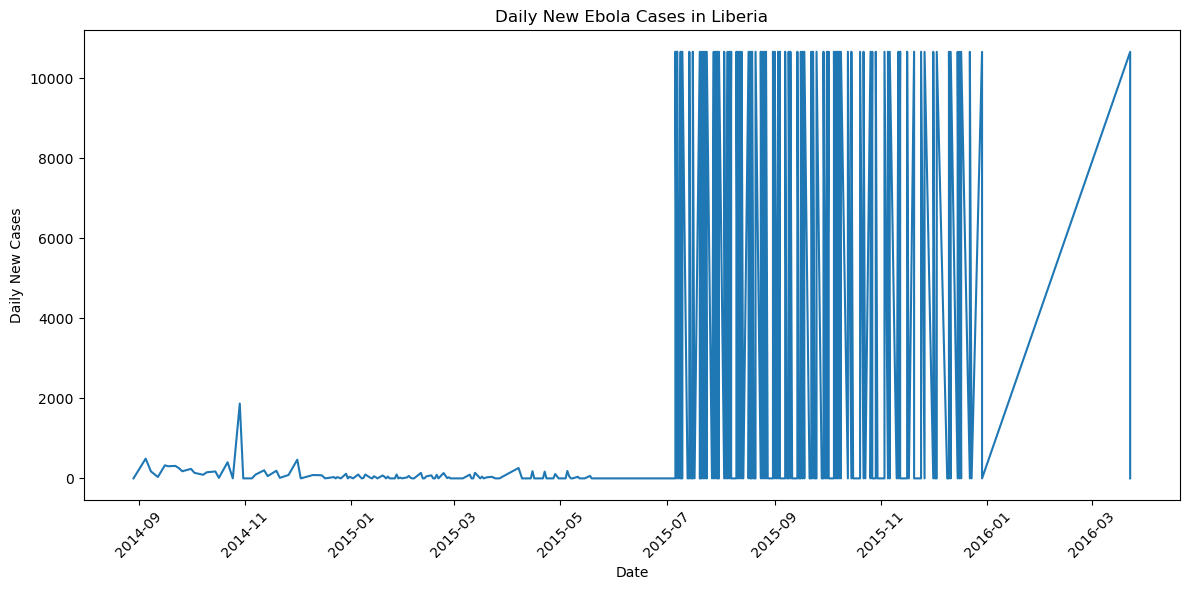

In [13]:
# import data
df = pd.read_csv("ebola_2014_2016_clean.csv")

# inspect data
print(df.shape)
print(df.head())

# filter data for only Liberia
df_liberia = df[df["Country"] == "Liberia"]
print(df_liberia.shape)
print(df_liberia.head())

# create a line plot of the cumulative number of cases over time
plt.plot(df_liberia["Date"], df_liberia["Cumulative no. of confirmed, probable and suspected cases"])
plt.title("Cumulative Number of Ebola Cases in Liberia")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.show()

#create a line plot of the cumulative number of deaths over time
plt.plot(df_liberia["Date"], df_liberia["Cumulative no. of confirmed, probable and suspected deaths"])
plt.title("Cumulative Number of Ebola Deaths in Liberia")
plt.xlabel("Date")
plt.ylabel("Number of Deaths")
plt.show()

# print the earliest and latest dates in the dataset
print("Earliest date:", df_liberia["Date"].min())
print("Latest date:", df_liberia["Date"].max())

# Make sure Date is actually treated as a datetime object
df_liberia["Date"] = pd.to_datetime(df_liberia["Date"])

# Sort by date so differences are calculated correctly
df_liberia = df_liberia.sort_values("Date")

# Create daily new cases from cumulative cases
df_liberia["Daily Cases"] = df_liberia["Cumulative no. of confirmed, probable and suspected cases"].diff()

# Create daily new deaths from cumulative deaths (optional but useful)
df_liberia["Daily Deaths"] = df_liberia["Cumulative no. of confirmed, probable and suspected deaths"].diff()

# Replace first NaN row (from diff) with 0
df_liberia["Daily Cases"] = df_liberia["Daily Cases"].fillna(0)
df_liberia["Daily Deaths"] = df_liberia["Daily Deaths"].fillna(0)

# If any reporting corrections created negative values, set them to 0 for cleaner visualization
df_liberia["Daily Cases"] = df_liberia["Daily Cases"].clip(lower=0)
df_liberia["Daily Deaths"] = df_liberia["Daily Deaths"].clip(lower=0)

# Plot daily new cases (bell-shaped epidemic curve)
plt.figure(figsize=(12,6))
plt.plot(df_liberia["Date"], df_liberia["Daily Cases"])
plt.title("Daily New Ebola Cases in Liberia")
plt.xlabel("Date")
plt.ylabel("Daily New Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
